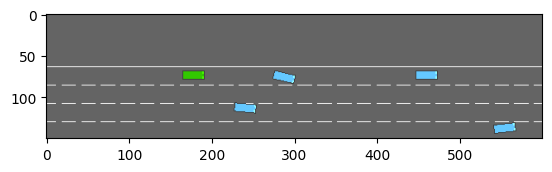

: 

In [ ]:
import gymnasium
import highway_env
from matplotlib import pyplot as plt
%matplotlib inline

env = gymnasium.make('highway-v0', render_mode='rgb_array')
env.reset()
for _ in range(3):
    action = env.unwrapped.action_type.actions_indexes["IDLE"]
    obs, reward, done, truncated, info = env.step(action)
    env.render()

plt.imshow(env.render())
plt.show()

In [31]:
import numpy as np
import pandas as pd
import random

In [ ]:
class GridCarEnv():
    def __init__(self, dims=(6,6), max_steps=200):
        self.dims = dims # (row, col)
        self.rewards = {
            'r_goal': 100, 
            'step': -1, 
            'hit_pitfall': -5,
            'bump_wall': -20}
        self.max_steps = max_steps
        self.start = (dims[0]-1, 0) # bottom left
        self.end = (0, dims[1]-1) # upper right
        self.positions = {'obstacles': [(1,4),(5,2),(4,6)]}
        self.pos = self.start
        self.reward_score = 0
        self.current_step = 0
        self.actions = { # 4 actions: 0=Up, 1=Down, 2=Left, 3=Right
            0: (-1,  0),
            1: ( 1,  0),
            2: ( 0, -1),
            3: ( 0,  1),
        }
    
    def reset(self):
        self.pos = self.start
        self.current_step = 0
        self.reward_score = 0
        return self.pos


    def step(self, move):

        reward = self.rewards['step']
        done = False
        self.current_step += 1
        if self.current_step == self.max_steps:
            done = True
            return self.pos, reward, done

        if move == 0:
            new_pos = (self.pos[0] + self.actions[0][0], self.pos[1]+ self.actions[0][1])
            if new_pos[0] == -1:
                reward += self.rewards['bump_wall']
            else:
                self.pos = new_pos #change position only if it is not out of bounds
        elif move == 1:
            new_pos = (self.pos[0] + self.actions[1][0], self.pos[1]+ self.actions[1][1])
            if new_pos[0] == self.dims[0]:
                reward += self.rewards['bump_wall']
            else:
                self.pos = new_pos
        elif move == 2:
            new_pos = (self.pos[0] + self.actions[2][0], self.pos[1]+ self.actions[2][1])
            if new_pos[1] == -1:
                reward += self.rewards['bump_wall']
            else:
                self.pos = new_pos
        elif move == 3:
            new_pos = (self.pos[0] + self.actions[3][0], self.pos[1]+ self.actions[3][1])
            if new_pos[1] == self.dims[1]:
                reward += self.rewards['bump_wall']
            else:
                self.pos = new_pos
        

        if self.pos in self.positions['obstacles']:
            self.reward_score = self.reward_score + self.rewards['hit_pitfall']
            reward += self.rewards['hit_pitfall'] 
        elif self.pos == self.end:
            reward += self.rewards['r_goal']
            done = True


        return self.pos, reward, done
    

def initialize_q_table(n_states,n_actions):
    q_table = np.zeros((n_states, n_actions))
    return q_table
def update_q_table(Q, alpha,r, gamma, a, s_old, s, dims):
    s_old = s_old[0] * dims[1] + s_old[1] # s_old is a tuple (e.g (2,3)) and needs to be indexed as an integer
    s = s[0] * dims[1] + s[1] # same as s_old
    print("s old, s, a ", s_old, s, a)
    Q[s_old,a] = Q[s_old,a] + alpha * ( r + gamma * np.max(Q[s,:]) - Q[s_old,a])

    return Q

env = GridCarEnv()
n_states = env.dims[0] * env.dims[1]  # 6*6 = 36
n_actions = len(env.actions)  # 4


total_reward = 0
alpha = 0.1
gamma = 0.1
epsilon = 1 # starts with full exploration
epsilon_min = 0.01 #always explore a little
epsilon_decay = 0.995 # how fast epsilon decreases
Q = initialize_q_table(n_states, n_actions)
episodes = 1000
for i in range(episodes):
    #while env.current_step < env.max_steps:
    s_old = env.pos

    # e-greedy policy
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    if np.random.random() < epsilon:
        action = np.random.choice(len(env.actions)) #choose a random action
    else:
        action = np.argmax(Q[s_old, :])

    pos, reward, done = env.step(action) #TODO: how next step is determined
    total_reward += reward
    #    if done == True:
    #        break
    Q = update_q_table(Q, alpha, reward, gamma, action, s_old, pos, env.dims)
print(Q)

    


    


action is:  1
s old, s, a  30 30 1
[[ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]
 [ 0.  -2.1  0.   0. ]
 [ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]]
